<font color='blue'> **10_convection.exponential1D.tri2D** </font>

In [23]:
from fipy import CellVariable, Tri2D, DiffusionTerm, ExponentialConvectionTerm, DefaultAsymmetricSolver, Viewer
from fipy.tools import numerix  ; import numpy as np  ; import matplotlib.pyplot as plt 

In [14]:
convCoeff = numerix.array(((10.,),(0.,) ))  ; convCoeff.shape

(2, 1)

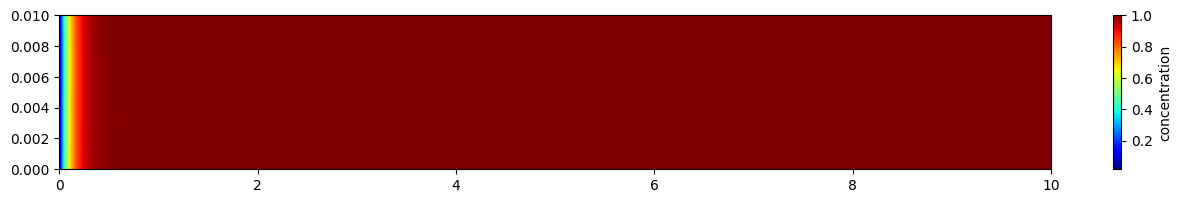

In [15]:
valueLeft = 0. ; valueRight = 1.    #; diffCoeff = 1. ; convCoeff = numerix.array(((0.,), (10.,)))

L = 10.; nx = 1000 ; ny = 1         ; mesh = Tri2D(dx = L / nx, dy = L / nx, nx = nx, ny = ny)     ; var = CellVariable(name = "concentration",mesh = mesh,value = valueLeft)
n='n'                               ; var.constrain(valueLeft, mesh.facesLeft)                 ; var.constrain(valueRight, mesh.facesRight)
eq = (DiffusionTerm(coeff=diffCoeff)+ ExponentialConvectionTerm(coeff=convCoeff))
n='n'                       ; solver = DefaultAsymmetricSolver(tolerance=1e-10, iterations=10000)  ; eq.solve(var=var, solver=solver)
viewer = Viewer(vars = var)

In [ ]:
print(var.shape)    ; print(mesh.shape)

(4000,)
(1, 1000)


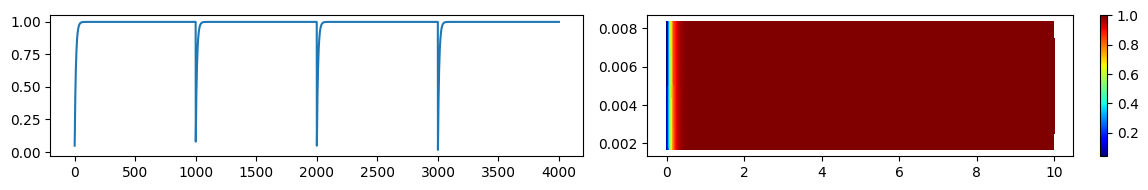

In [ ]:
YY=var.value  ;XX=np.linspace(0,len(YY)-1,num=len(YY))                                               
xx = mesh.cellCenters[0].value   ; yy = mesh.cellCenters[1].value   ; zz = var.value  ; ZZ = zz

fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(12, 2))                # ; print(valueBottomRight)
ax1.plot(XX,YY)          

WW = ax2.tripcolor(yy,xx, ZZ,cmap='jet') ;  cbar = plt.colorbar(WW)  ; plt.tight_layout() ;  plt.show()

In [17]:
valueBottom = 0. ; valueTop = 1.    ; diffCoeff = 1. ; convCoeff = numerix.array(((0.,), (10.,)))

L = 10.; nx = 1 ; ny = 1000         ; mesh = Tri2D(dx = L / ny, dy = L / ny, nx = nx, ny = ny)     ; var = CellVariable(name = "concentration",mesh = mesh,value = valueBottom)
n='n'                               ; var.constrain(valueBottom, mesh.facesBottom)                 ; var.constrain(valueTop, mesh.facesTop)
eq = (DiffusionTerm(coeff=diffCoeff)+ ExponentialConvectionTerm(coeff=convCoeff))
n='n'                       ; solver = DefaultAsymmetricSolver(tolerance=1e-10, iterations=10000)  ; eq.solve(var=var, solver=solver)
#viewer = Viewer(vars = var)